## Punto 4:

Descomponga en fracciones parciales las siguientes funciones racionales

$$
F(s)=\frac{52.5s(s+1)(s+1.5)(s+5)}{s^4+20.75s^3+92.6s^2+73.69s}
$$

es decir, determine las raíces utilizando un método de búsqueda de raíces, use los 4 métodos para determinar una raíz diferente.

## Solución

### Definición de la función

La función dada en el ejercicio es:

$$
F(s)=\frac{52.5s(s+1)(s+1.5)(s+5)}{s^4+20.75s^3+92.6s^2+73.69s}
$$

Para encontrar las raíces utilizando métodos numéricos, primero debemos analizar **el denominador de la función**.

Esto se debe a que las raíces del denominador corresponden a los valores de \(s\) que hacen que:

$$
s^4+20.75s^3+92.6s^2+73.69s = 0
$$

Por lo tanto, se define esta expresión como una función \(f(s)\), la cual será utilizada para aplicar los métodos numéricos de búsqueda de raíces (Bisección, Falsa Posición y Newton).

Esta función se define en Python para poder evaluarla en distintos valores de \(s\).

In [34]:
import importlib
import ceros_de_funcion
importlib.reload(ceros_de_funcion)
from ceros_de_funcion import *

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

f= lambda s: (s**4) + (20.75)*s**3 + (92.6)*s**2 + (73.69)*s


### Gráfica de la función

Es útil observar cómo se comporta la función.  
Para esto se realiza una gráfica del denominador de la función.

La gráfica nos ayuda a identificar aproximadamente en qué valores de \(s\) la función
puede cruzar el eje \(x\). Cuando la gráfica cruza el eje \(x\), significa que la función
toma el valor cero en ese punto, es decir, que allí existe una raíz.

Con esta gráfica podemos tener una primera idea de dónde buscar las raíces y así elegir
intervalos adecuados para aplicar los métodos numéricos.

(-10.0, 200.0)

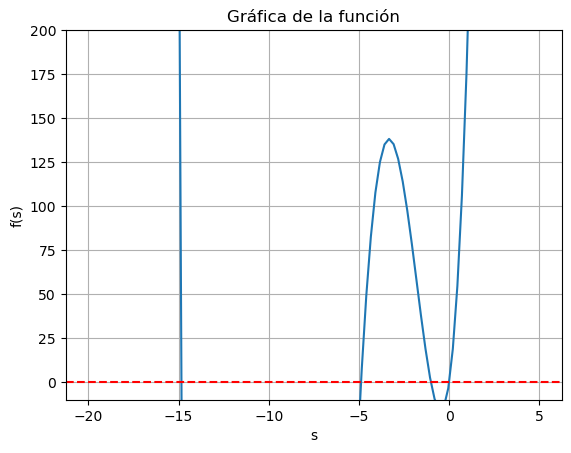

In [60]:
ux = np.linspace(-20,5,100)

plt.plot(ux,f(ux))
plt.axhline(0,linestyle="--",color="red")

plt.title("Gráfica de la función")
plt.xlabel("s")
plt.ylabel("f(s)")
plt.grid()
plt.ylim(-10,200)

### Tabla de valores

Después de observar la gráfica, se evalúa la función en varios valores de \(s\).
Esto se hace para ver con más claridad en qué intervalos la función cambia de signo.

Cuando la función cambia de signo entre dos valores consecutivos, significa que
entre esos dos puntos debe existir una raíz.

Por ejemplo, si en un punto la función es positiva y en el siguiente es negativa,
entonces la función tuvo que pasar por cero en algún punto entre ellos.

Esto permite identificar intervalos donde se pueden aplicar los métodos numéricos
como bisección o falsa posición.

In [56]:
print("   x        f(x)")
print("----------------------")

for i in range(-20,5):
    print(f"{i:>5}   {f(i):>10.2f}")

   x        f(x)
----------------------
  -20     29566.20
  -19     20025.24
  -18     12637.98
  -17      7084.92
  -16      3070.56
  -15       323.40
  -14     -1404.06
  -13     -2335.32
  -12     -2669.88
  -11     -2583.24
  -10     -2226.90
   -9     -1728.36
   -8     -1191.12
   -7      -694.68
   -6      -294.54
   -5       -22.20
   -4       114.84
   -3       133.08
   -2        73.02
   -1        -0.84
    0         0.00
    1       188.04
    2       699.78
    3      1695.72
    4      3360.36


### Identificación de intervalos con raíces

Al observar los valores obtenidos en la tabla se pueden notar algunos cambios de signo.
Estos cambios indican que existe una raíz entre esos dos valores.

Los intervalos donde ocurre esto son:

- entre -15 y -14  
- entre -5 y -4  
- entre -2 y -1  

Además, se puede observar que:

\(f(0) = 0\)

lo que significa que \(s = 0\) también es una raíz de la función.

Estos intervalos se utilizarán para aplicar los métodos numéricos y encontrar
aproximaciones de las raíces.

### Método de Bisección

El método de bisección consiste en tomar un intervalo donde la función cambie de signo.
Si la función es positiva en un punto y negativa en otro, significa que en algún lugar
entre esos dos valores la función debe ser cero, es decir, que hay una raíz.

Según la tabla de valores calculada anteriormente se observa que:

- \(f(-2) < 0\)
- \(f(-1) > 0\)

Esto indica que entre -2 y -1 existe una raíz.

El método de bisección funciona tomando el punto medio del intervalo y evaluando la función
en ese punto. Dependiendo del signo obtenido, se reduce el intervalo a la mitad y se repite
el proceso hasta encontrar una aproximación de la raíz con el error deseado.

In [49]:
raiz_bis, iter_bis = biseccion(f,-2,-1,1e-3)

print("Raiz biseccion:",raiz_bis)
print("Iteraciones:",iter_bis)

Raiz biseccion: -1.015625
Iteraciones: 6


### Método de Falsa Posición

El método de falsa posición es parecido al de bisección porque también utiliza
un intervalo donde la función cambia de signo.

La diferencia es que en lugar de tomar el punto medio del intervalo,
este método calcula un punto donde una recta que une los dos extremos
del intervalo cruza el eje \(x\).

Este punto suele estar más cerca de la raíz que el punto medio,
por lo que en muchos casos el método puede acercarse más rápido
a la solución.

Para este método se utiliza el intervalo donde se observó otro cambio
de signo en la tabla de valores.

In [ ]:
raiz_fp, iter_fp = pos_falsa(f,-5,-4,1e-3)

print("Raiz falsa posicion:",raiz_fp)
print("Iteraciones:",iter_fp)

Raiz falsa posicion: -1.1259219483639171e-05
Iteraciones: 32


### Método de Newton

El método de Newton funciona de forma diferente a los métodos anteriores.
En lugar de usar un intervalo, este método necesita un valor inicial
cercano a la raíz.

A partir de ese valor inicial, el método utiliza la derivada de la función
para ir calculando mejores aproximaciones de la raíz.

La idea del método es trazar la recta tangente a la función en el punto inicial
y ver dónde esa recta corta el eje \(x\). Ese nuevo punto se usa como la
siguiente aproximación.

Repitiendo este proceso varias veces se obtiene un valor cada vez más
cercano a la raíz.

In [61]:
x = sp.symbols('x')
f_sym = (x**4) + (20.75)*x**3 + (92.6)*x**2 + (73.69)*x

raiz_newton, iter_newton = Newton(f_sym,1,1e-3)

print("Raiz newton:",raiz_newton)
print("Iteraciones:",iter_newton)

Raiz newton: 8.592828546703226e-08
Iteraciones: 5


# Método de Secante


In [ ]:
raiz_sec = secante(f,-15,-14,1e-3)

print("Raiz secante:",raiz_sec)

Raiz secante: -14.847553085288695
